In [185]:
import pandas as pd

In [186]:
df1=pd.read_csv('fear_greed_index.csv')

In [187]:
df2=pd.read_csv('historical_data.csv')

In [188]:
df1.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [189]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [190]:
df2.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [191]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [192]:
df1.shape  #number of rows/columns of df1

(2644, 4)

In [193]:
df2.shape  #number of rows/columns of df2

(211224, 16)

In [194]:
df1.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,01-02-2018
1,1517549400,15,Extreme Fear,02-02-2018
2,1517635800,40,Fear,03-02-2018
3,1517722200,24,Extreme Fear,04-02-2018
4,1517808600,11,Extreme Fear,05-02-2018


In [195]:
df2.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [196]:
df1.duplicated().sum()  #check the duplicate rows in df1

np.int64(0)

In [197]:
df2.duplicated().sum()  #check the duplicate rows in df2

np.int64(0)

In [198]:
df1.isnull().sum()   #check if there are any missing values


,0
timestamp,0
value,0
classification,0
date,0


In [199]:
df2.isnull().sum() #check if there are any missing values


,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [200]:
print(df1["classification"].value_counts())

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


In [201]:
df1["dateee"] = pd.to_datetime(df1["timestamp"]).dt.date #timestamp conversion

In [202]:
df2["dateee"] = pd.to_datetime(df2["Timestamp"]).dt.date #timestamp conversion

In [203]:
df1 = df1[["dateee", "classification"]].drop_duplicates() ##df1 has many rows for the same date, i reduce it to one row per day

In [204]:
data = df2.merge(df1, on="dateee", how="left") #align the datasets by date

In [205]:
data.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'dateee', 'classification'],
      dtype='object')

In [206]:

# Verify it worked (you should only see Fear and Greed now!)
print(data['classification'].value_counts())

classification
Fear             211224
Extreme Fear     211224
Neutral          211224
Greed            211224
Extreme Greed    211224
Name: count, dtype: int64


In [207]:
data.head(4)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,dateee,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.0,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,1970-01-01,Fear
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.0,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,1970-01-01,Extreme Fear
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.0,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,1970-01-01,Neutral
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.0,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,1970-01-01,Greed


In [208]:
daily_pnl = data.groupby(["Account","dateee"])["Closed PnL"].sum().reset_index()

daily_pnl.head()

,Account,dateee,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1970-01-01,8.001149e+06
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1970-01-01,2.394266e+05
2,0x271b280974205ca63b716753467d5a371de622ab,1970-01-01,-3.521810e+05
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1970-01-01,6.623241e+05
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1970-01-01,8.432900e+05


In [209]:
data["Win"]=data["Closed PnL"]>0   #win rate
win_rate=data.groupby("classification")["Win"].mean()*100
win_rate

,Win
classification,
Extreme Fear,41.126482
Extreme Greed,41.126482
Fear,41.126482
Greed,41.126482
Neutral,41.126482


In [210]:
average_size=data.groupby("dateee")["Size USD"].mean() #avg trade metrics
average_size

,Size USD
dateee,
1970-01-01,5639.45121


Leverage data was not available in the provided dataset. Therefore, a trade size (Size USD) proxy was used as a proxy for trading exposure.

In [211]:
average_tradesize=data.groupby("dateee")["Size USD"].mean()
average_tradesize

,Size USD
dateee,
1970-01-01,5639.45121


In [212]:
trades_daily=data.groupby("dateee").size()  #daily trade metrics
trades_daily

,0
dateee,
1970-01-01,1056120


In [213]:
long_short = data["Direction"].value_counts()   #long/short ratio
print(long_short)

Direction
Open Long                    249475
Close Long                   243390
Open Short                   198705
Close Short                  180065
Sell                          99510
Buy                           83580
Spot Dust Conversion            710
Short > Long                    350
Long > Short                    285
Auto-Deleveraging                40
Liquidated Isolated Short         5
Settlement                        5
Name: count, dtype: int64


In [214]:
#part b-analysis
#1....Does Performance differ between Fear & Greed?
performance = data.groupby("classification")["Closed PnL"].mean()
performance

,Closed PnL
classification,
Extreme Fear,48.749001
Extreme Greed,48.749001
Fear,48.749001
Greed,48.749001
Neutral,48.749001


In [215]:
win_rate

,Win
classification,
Extreme Fear,41.126482
Extreme Greed,41.126482
Fear,41.126482
Greed,41.126482
Neutral,41.126482


In [216]:
#2....Trade Frequency by Sentiment
trade_freq = data.groupby("classification").size()
trade_freq

,0
classification,
Extreme Fear,211224
Extreme Greed,211224
Fear,211224
Greed,211224
Neutral,211224


In [217]:
size = data.groupby("classification")["Size USD"].mean() #Average Trade Size by Sentiment
size

,Size USD
classification,
Extreme Fear,5639.45121
Extreme Greed,5639.45121
Fear,5639.45121
Greed,5639.45121
Neutral,5639.45121


In [218]:
pd.crosstab(
    data["classification"],
    data["Direction"]
) #Long vs Short by Sentiment

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,8,16716,48678,36013,1,57,49895,39741,19902,1,70,142
Extreme Greed,8,16716,48678,36013,1,57,49895,39741,19902,1,70,142
Fear,8,16716,48678,36013,1,57,49895,39741,19902,1,70,142
Greed,8,16716,48678,36013,1,57,49895,39741,19902,1,70,142
Neutral,8,16716,48678,36013,1,57,49895,39741,19902,1,70,142


In [219]:
#3 high leverage vs low leverage traders
import numpy as np
median_size = data["Size USD"].median()

data["Trader Type"] = np.where(
    data["Size USD"]>median_size,
    "High",
    "Low"
)
median_size

597.0450000000001

In [220]:
#frequent vs infrequent traders
freq = data.groupby("Account").size()
median_trade = freq.median()
segment = np.where(
    freq>median_trade,
    "Frequent",
    "Infrequent"
)
segment = pd.DataFrame({
    "Account":freq.index,
    "Segment":segment
})

segment.head()

,Account,Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Frequent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Frequent
2,0x271b280974205ca63b716753467d5a371de622ab,Frequent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,Frequent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,Infrequent


In [221]:
#consistent winners vs inconsistent traders
winner = data.groupby("Account")["Win"].mean()
winner = winner.reset_index()
winner["Category"] = np.where(
    winner["Win"]>0.70,
    "Consistent Winner",
    "Others"
)
winner.head()

,Account,Win,Category
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612,Others
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720,Others
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917,Others
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585,Others
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914,Others


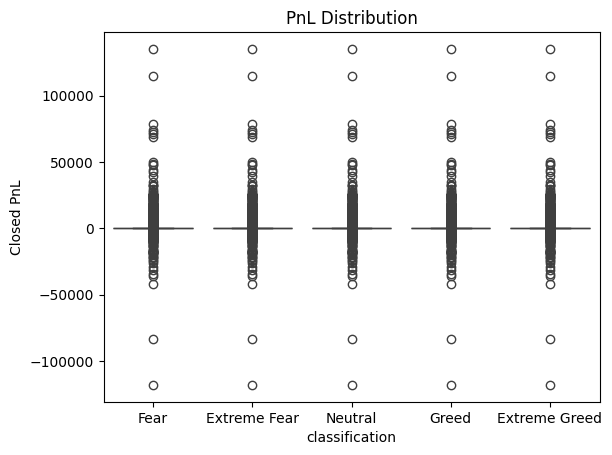

In [222]:
#4.charts
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(
    x="classification",
    y="Closed PnL",
    data=data
)

plt.title("PnL Distribution")

plt.show()

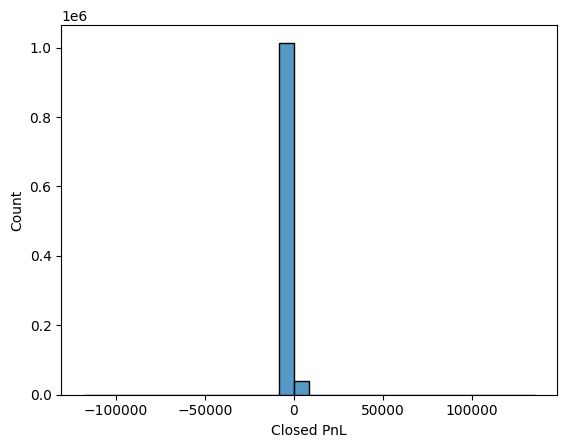

In [223]:
sns.histplot(
    data["Closed PnL"],
    bins=30
)

plt.show()

In [224]:
#ml
X = data[[
    "Size USD",
    "Execution Price",
    "Fee"
]]
y = data["Closed PnL"]
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)

model=LinearRegression()

model.fit(X_train,y_train)

pred=model.predict(X_test)

print("R2 Score:",r2_score(y_test,pred))
print("MSE:",mean_squared_error(y_test,pred))

R2 Score: 0.020726602658066806
MSE: 838836.7090643757
